In [7]:
!pip install kaggle

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!mkdir -p ~/.kaggle
!cp #add the location of json file of kaggle Api
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [12]:
!ls

data  drive  face-mask-dataset.zip  sample_data


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten,Conv2D,MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam

In [14]:
with_mask_files=os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_3392.jpg', 'with_mask_440.jpg', 'with_mask_1206.jpg', 'with_mask_2781.jpg', 'with_mask_1059.jpg']
['with_mask_3151.jpg', 'with_mask_3637.jpg', 'with_mask_1705.jpg', 'with_mask_27.jpg', 'with_mask_2987.jpg']


In [ ]:
without_mask_files=os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2819.jpg', 'without_mask_2555.jpg', 'without_mask_908.jpg', 'without_mask_3042.jpg', 'without_mask_1486.jpg']
['without_mask_1383.jpg', 'without_mask_438.jpg', 'without_mask_1264.jpg', 'without_mask_3775.jpg', 'without_mask_3100.jpg']


In [ ]:
print('length of masked images',len(with_mask_files))
print('length of without mask images',len(without_mask_files))

length of masked images 3725
length of without mask images 3828


In [ ]:
# label for wearing mask 1
# label for without wearing mask 2

with_mask_labels=[1]*len(with_mask_files)
without_mask_labels=[0]*len(without_mask_files)

In [ ]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [ ]:
labels=with_mask_labels+without_mask_labels
len(labels)

7553

In [ ]:
print(labels[0:5])
print(labels[-5:])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


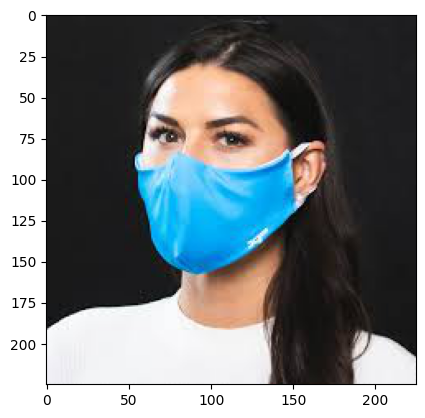

In [ ]:
# Display with mask image
img=mpimg.imread('/content/data/with_mask/with_mask_822.jpg')
imgplot=plt.imshow(img)

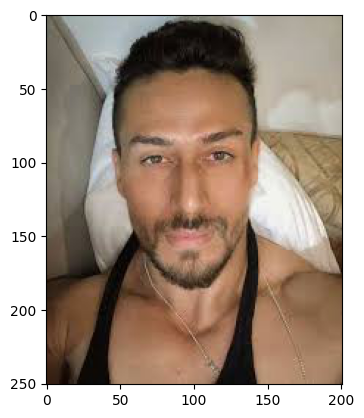

In [ ]:
img=mpimg.imread('/content/data/without_mask/without_mask_766.jpg')
imgplot=plt.imshow(img)

# Image Processing

In [ ]:
# converting images to nparray for faster processing
with_mask_path='/content/data/with_mask/'

data=[]

for img_file in with_mask_files:
  image=Image.open(with_mask_path+img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)


without_mask_path='/content/data/without_mask/'

for img_file in without_mask_files:
  image=Image.open(without_mask_path+img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
len(data)

7553

In [ ]:
data[10]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 152,   4],
        [255, 153,   0],
        [254, 153,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 152,   4],
        [255, 153,   0],
        [254, 153,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 152,   4],
        [255, 153,   0],
        [254, 153,   0]],

       ...,

       [[ 23,  17,  21],
        [ 22,  16,  20],
        [ 20,  14,  18],
        ...,
        [ 60,  52,  47],
        [ 36,  33,  33],
        [ 26,  23,  27]],

       [[ 23,  17,  21],
        [ 22,  16,  20],
        [ 20,  14,  18],
        ...,
        [ 50,  41,  35],
        [ 26,  22,  21],
        [ 19,  15,  19]],

       [[ 23,  17,  21],
        [ 22,  16,  20],
        [ 21,  15,  19],
        ...,
        [ 27,  22,  21],
        [ 19,  15,  16],
        [ 22,  18,  20]]

In [ ]:
type(data)

list

In [ ]:
type(data[10])

numpy.ndarray

In [ ]:
data[10].shape

(128, 128, 3)

In [ ]:
X=np.array(data)
y=np.array(labels)

In [ ]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print(X.shape)
print(y.shape)

(7553, 128, 128, 3)
(7553,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
# Normalising
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [ ]:
# CNN

In [ ]:
model=Sequential()

model.add(Conv2D(16,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2,activation='sigmoid'))


In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 64)       0

In [ ]:
# training the neural network
history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 [==============================] - 15s 16ms/step - loss: 0.4317 - accuracy: 0.8039 - val_loss: 0.2391 - val_accuracy: 0.8975
Epoch 2/10
170/170 [==============================] - 2s 13ms/step - loss: 0.2747 - accuracy: 0.8953 - val_loss: 0.1838 - val_accuracy: 0.9306
Epoch 3/10
170/170 [==============================] - 2s 13ms/step - loss: 0.2231 - accuracy: 0.9137 - val_loss: 0.1551 - val_accuracy: 0.9438
Epoch 4/10
170/170 [==============================] - 2s 12ms/step - loss: 0.1928 - accuracy: 0.9272 - val_loss: 0.1300 - val_accuracy: 0.9488
Epoch 5/10
170/170 [==============================] - 2s 12ms/step - loss: 0.1697 - accuracy: 0.9349 - val_loss: 0.1475 - val_accuracy: 0.9471
Epoch 6/10
170/170 [==============================] - 2s 12ms/step - loss: 0.1419 - accuracy: 0.9456 - val_loss: 0.1448 - val_accuracy: 0.9587
Epoch 7/10
170/170 [==============================] - 2s 12ms/step - loss: 0.1327 - accuracy: 0.9557 - val_loss: 0.1379 - val_accuracy: 0.960

In [ ]:
loss,accuracy=model.evaluate(X_test_scaled,y_test)
print('Test_accuracy: ',accuracy)
print('Test loss: ',loss)

48/48 [==============================] - 0s 7ms/step - loss: 0.1609 - accuracy: 0.9530
Test_accuracy:  0.9530112743377686
Test loss:  0.16086067259311676


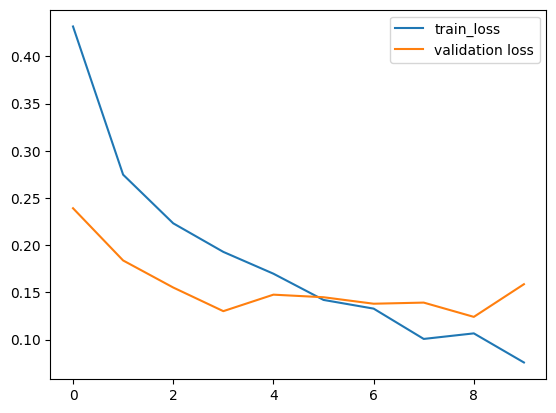

In [ ]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

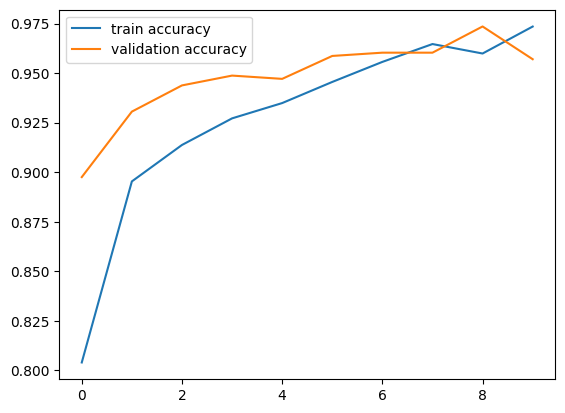

In [ ]:
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

In [ ]:
# prediction
def prediction():
  input_image_path=input('Enter The Path : ' )
  input_image=cv2.imread(input_image_path)
  cv2_imshow(input_image)
  input_image_resized=cv2.resize(input_image,(128,128))
  input_image_scaled=input_image_resized/255
  input_image_reshaped=np.reshape(input_image_scaled,(1,128,128,3))
  input_prediction=model.predict(input_image_reshaped)
  # print(input_prediction)
  input_pred_label=np.argmax(input_prediction)
  # print(input_pred_label)
  if input_pred_label==1:
    print('wearing_mask')
  else:
    print('Not wearing_mask')

Enter The Path : /content/mask2.jpg


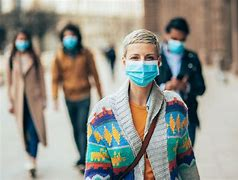

1/1 [==============================] - 0s 207ms/step
wearing_mask


In [ ]:
prediction()